## ARC-AGI-1 with Neural Cellular Automata (NCA)

Notebook to reproduce the rollout visualizations and figures from the paper.

### Content:
1. **Setup & Hyperparameters (Sections 1–2)**: Defines the 512-channel NCA state layout and setup new checkpoints/datasets in accelerator memory.

2. **Core Utilities & JAX NCA Model (Sections 3–5)**: Implements async local-time NCA rollouts.

3. **Evaluation Task Rollout (Section 6)**: Runs a 64-step rollout on a test-time augmented evaluation puzzle (`"33b52de3"`).

4. **Task-embedding transfer on OOD "CA" text (Section 7)**: Conditions the pretrained NCA on learned task embeddings (`101`, `197`) while initializing the grid with a synthetic $32 \times 32$ `"CA"` text.


In [1]:

# @title 1. environment setup, imports & hyperparams

import base64
from functools import partial
import io
import os
import pickle
from typing import Any, Dict, List, Optional, Tuple

from IPython.display import HTML, display
import jax
from jax import jit, lax, vmap
import jax.numpy as jnp
import jax.random as jr
from matplotlib.animation import FFMpegWriter, FuncAnimation
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


CHECKPOINT_DIR_EVAL = "./checkpoints/eval/"  # @param {type:"string"}
CHECKPOINT_PRETRAIN = "./checkpoints/pretrained/checkpoint_pretrained.pkl" # @param {type:"string"}
AUGMENTED_EVAL_DIR = "./augmented_eval/"  # @param {type:"string"}
OUTPUT_DIR = "./outputs"  # @param {type:"string"}
HF_ARC_REPO = "https://huggingface.co/datasets/dataartist/arc-agi/resolve/main/data"


ROLLOUT_TASK_ID = "33b52de3"  # @param {type:"string"}
ROLLOUT_SAMPLE_IDX = 13
ROLLOUT_TRAIN_TASK_ID = "007bbfb7"  # @param {type:"string"}
ROLLOUT_ITER_N = 64
ROLLOUT_SEED = 42
ROLLOUT_SHOW_TARGET = True

# 512-Channel Cell State Layout:
#   [0 : 32]    INPUT_EMB_D  — Immutable input token embedding
#   [32 : 160]  TASK_EMB_D   — Mutable task embedding
#   [160 : 192] OUTPUT_EMB_D — Readout slice projected to 12 tokens (0-9 colors, 10 border, 11 pad)
#   [192 : 512] HIDDEN_D     — Working memory where per-cell local-time embeddings are added
CHANNEL_N = 512
INPUT_EMB_D = 32
TASK_EMB_D = 128
OUTPUT_EMB_D = 32
HIDDEN_D = CHANNEL_N - INPUT_EMB_D - TASK_EMB_D - OUTPUT_EMB_D
NUM_UNITS = 32
BORDER_INDEX = 10
PAD_INDEX = 11
CELL_FIRE_RATE = 0.9
STEP_SIZE = 1.0

OUTPUT_SLICE = slice(INPUT_EMB_D + TASK_EMB_D, INPUT_EMB_D + TASK_EMB_D + OUTPUT_EMB_D)
HIDDEN_SLICE = slice(INPUT_EMB_D + TASK_EMB_D + OUTPUT_EMB_D, CHANNEL_N)

ARC_COLORS = [
    "#000000",  # 0: Black
    "#0074D9",  # 1: Blue
    "#FF4136",  # 2: Red
    "#2ECC40",  # 3: Green
    "#FFDC00",  # 4: Yellow
    "#AAAAAA",  # 5: Grey
    "#F012BE",  # 6: Magenta
    "#FF851B",  # 7: Orange
    "#7FDBFF",  # 8: Teal
    "#870E25",  # 9: Maroon
]
ARC_CMAP = ListedColormap(ARC_COLORS)
ARC_NORM = BoundaryNorm(np.arange(-0.5, 10.5, 1), ARC_CMAP.N)

!pip install --upgrade "numpy>=2.0"


/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [4]:

# @title 2. checkpoint and dataset load

def read_pickle(path: str, label: str = "file") -> Any:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {label} at path: {os.path.abspath(path)}")
    try:
        with open(path, "rb") as f:
            return pickle.load(f)
    except Exception as e:
        raise RuntimeError(f"Failed to read {label} from {path}: {e}") from e

def load_checkpoint(pkl_path: str) -> Dict[str, Any]:
    print(f"Loading checkpoint from disk: {pkl_path}")
    task_dict = read_pickle(pkl_path, label="checkpoint")
    return jax.device_put(jax.tree.map(jnp.asarray, task_dict["params"]))


def _pad_arc_grid(g: Any, is_target: bool = False) -> np.ndarray:
    arr = np.asarray(list(map(list, g)), dtype=np.int8)
    h, w = arr.shape
    out = np.full((32, 32), PAD_INDEX, dtype=np.int8)
    if is_target:
        out[: min(h + 1, 32), : min(w + 1, 32)] = BORDER_INDEX
    out[:h, :w] = arr
    return out


def _apply_forward_aug(g: np.ndarray, info: Dict[str, Any]) -> np.ndarray:
    geom = info.get("geom", "Identity")
    if "Rotate(90)" in geom:
        g = np.rot90(g, k=1)
    elif "Rotate(180)" in geom:
        g = np.rot90(g, k=2)
    elif "Rotate(270)" in geom:
        g = np.rot90(g, k=3)
    elif "Flip(0)" in geom:
        g = np.flipud(g)
    elif "Flip(1)" in geom:
        g = np.fliplr(g)
    lookup = np.arange(12, dtype=np.int8)
    for k, v in (info.get("color_map") or {}).items():
        lookup[int(k)] = int(v)
    return lookup[g]


def _load_hf_split(split: str):
    import pandas as pd, ssl, urllib.request
    cache_path = f"/tmp/arc_agi_{split}.parquet"
    if not os.path.exists(cache_path):
        ctx = ssl._create_unverified_context()
        url = f"{HF_ARC_REPO}/{split}-00000-of-00001.parquet"
        with urllib.request.urlopen(url, context=ctx) as r, open(cache_path, "wb") as f:
            f.write(r.read())
    return pd.read_parquet(cache_path)


def load_task_data_from_dir(
    task_id: str
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    train_ids = sorted(_load_hf_split("training")["id"])
    if task_id in train_ids:
        mask = t_ids == train_ids.index(task_id)
        return t_inputs[mask], t_targets[mask], t_ids[mask]
    df_ev = _load_hf_split("evaluation")
    row = df_ev[df_ev["id"] == task_id].iloc[0]
    raw_in = np.asarray(list(map(list, row["test"][0]["input"])), dtype=np.int8)
    raw_tgt = np.asarray(list(map(list, row["test"][0]["output"])), dtype=np.int8)
    aug_info = read_pickle(os.path.join(AUGMENTED_EVAL_DIR, f"{task_id}.pkl"))["aug_info"]
    inputs = np.stack([_pad_arc_grid(_apply_forward_aug(raw_in, inf), False) for inf in aug_info])
    targets = np.stack([_pad_arc_grid(_apply_forward_aug(raw_tgt, inf), True) for inf in aug_info])
    return inputs, targets, np.arange(len(aug_info), dtype=np.int32)


def load_state_and_data(
    ckpt_path: str
) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray, np.ndarray]:
    df_tr = _load_hf_split("training").sort_values("id").reset_index(drop=True)
    t_in, t_tgt, t_id = [], [], []
    for tid, row in df_tr.iterrows():
        for pair in row["test"]:
            t_in.append(_pad_arc_grid(pair["input"], False))
            t_tgt.append(_pad_arc_grid(pair["output"], True))
            t_id.append(tid)
    return (
        load_checkpoint(ckpt_path),
        np.stack(t_in),
        np.stack(t_tgt),
        np.array(t_id, dtype=np.int32),
    )

# load checkpoints of pre-trained and fine-tuned
sample_checkpoint = os.path.join(CHECKPOINT_DIR_EVAL, f"{ROLLOUT_TASK_ID}.pkl")
eval_params = load_checkpoint(sample_checkpoint)
params, t_inputs, t_targets, t_ids = load_state_and_data(CHECKPOINT_PRETRAIN)

Loading checkpoint from disk: ./checkpoints/eval/33b52de3.pkl
Loading checkpoint from disk: ./checkpoints/pretrained/checkpoint_pretrained.pkl


In [5]:

# @title 3. utils: Geometry, Color Inversion & Cropping
def apply_inverse_geom(grid: np.ndarray, augmenter_str: Optional[str]) -> np.ndarray:
    """Inverts spatial transformations (rotations and flips)."""
    array = np.asarray(grid)
    if not augmenter_str or augmenter_str == "Identity":
        return array
    if "Rotate(90)" in augmenter_str:
        return np.rot90(array, k=3)
    if "Rotate(180)" in augmenter_str:
        return np.rot90(array, k=2)
    if "Rotate(270)" in augmenter_str:
        return np.rot90(array, k=1)
    if "Flip(0)" in augmenter_str:
        return np.flipud(array)
    if "Flip(1)" in augmenter_str:
        return np.fliplr(array)
    return array

def apply_inverse_color(
    grid: np.ndarray, inverse_color_map_raw: Optional[Dict[Any, Any]]
) -> np.ndarray:
    """Inverts color permutation using a 12-element lookup vector."""
    lookup = np.arange(12, dtype=np.int32)
    if inverse_color_map_raw:
        for k, v in inverse_color_map_raw.items():
            lookup[int(k)] = int(v)
    grid_arr = np.asarray(grid, dtype=np.int32)
    return lookup[np.clip(grid_arr, 0, len(lookup) - 1)]


def unaugment_grid(grid: np.ndarray, aug_info: Dict[str, Any]) -> np.ndarray:
    """Inverts both geometric and color augmentations."""
    return apply_inverse_color(
        apply_inverse_geom(grid, aug_info.get("geom")),
        aug_info.get("inverse_color_map"),
    )


def get_content_bounds(
    grid: np.ndarray, pad_values: Tuple[int, ...] = (10, 11), margin: int = 0
) -> Tuple[int, int, int, int]:
    """Returns (y_min, y_max, x_min, x_max) of active non-padding tokens (supports 2D or 3D)."""
    valid = ~np.isin(grid, pad_values)
    if valid.ndim == 3:
        valid = np.any(valid, axis=0)
    h, w = valid.shape
    rows, cols = np.where(valid)
    return (
        max(0, int(rows.min()) - margin),
        min(h - 1, int(rows.max()) + margin),
        max(0, int(cols.min()) - margin),
        min(w - 1, int(cols.max()) + margin),
    )


def crop_target(
    grid: np.ndarray, pad_values: Tuple[int, ...] = (10, 11)
) -> np.ndarray:
    """Crops padding and border tokens around the active content grid."""
    y0, y1, x0, x1 = get_content_bounds(grid, pad_values)
    return grid[y0 : y1 + 1, x0 : x1 + 1]

In [6]:

# @title 4. NCA architecture

@partial(jit, static_argnames=("num_units",))
def groupnorm(emb: jnp.ndarray, num_units: int) -> jnp.ndarray:
    """Applies group normalization across channel subgroups."""
    orig_shape = emb.shape
    emb = emb.reshape(orig_shape[:-1] + (num_units, orig_shape[-1] // num_units))
    sq_norm = jnp.sum(emb**2, axis=-1, keepdims=True)
    return (emb / jnp.sqrt(sq_norm + 1e-6)).reshape(orig_shape)


@jit
def normalize_state(x_state: jnp.ndarray) -> jnp.ndarray:
    """Normalizes mutable state channels while keeping input embeddings intact."""
    mut_channels = CHANNEL_N - INPUT_EMB_D
    mut_units = NUM_UNITS * mut_channels // CHANNEL_N

    x_immutable = x_state[..., :INPUT_EMB_D]
    x_mutable = groupnorm(x_state[..., INPUT_EMB_D:], mut_units)
    return jnp.concatenate([x_immutable, x_mutable], axis=-1)


def stack_neighbors(x: jnp.ndarray) -> jnp.ndarray:
    """Extracts 3x3 Moore neighborhood patches around each spatial cell."""
    x_pad = jnp.pad(
        x, ((1, 1), (1, 1), (0, 0)), mode="constant", constant_values=0.0
    )
    return jnp.stack(
        [
            x_pad[dr : dr + x.shape[0], dc : dc + x.shape[1], :]
            for dr in range(3)
            for dc in range(3)
        ],
        axis=-2,
    )

def swiglu(x: jnp.ndarray, params: Dict[str, jnp.ndarray]) -> jnp.ndarray:
    """Applies SwiGLU MLP update to perceived cell features."""
    gate = (params["wg"] @ x[..., None])[..., 0] + params["bg"]
    value = (params["w1"] @ x[..., None])[..., 0] + params["b1"]
    out = jax.nn.swish(gate) * value
    return (params["w2"] @ out[..., None])[..., 0] + params["b2"]

def state_init(
    params: Dict[str, Any],
    x: jnp.ndarray,
    local_tid: int,
    key: jax.Array,
) -> jnp.ndarray:
    """Initializes the NCA spatial grid state from discrete input tokens and task ID."""
    h, w = x.shape
    _, key_hidden = jr.split(key)
    task_embs = params["task_embedding"][
        local_tid % params["task_embedding"].shape[0]
    ]
    task_embs_tiled = jnp.broadcast_to(
        task_embs[None, None, :], (h, w, TASK_EMB_D)
    )
    token_embs = params["token_embeddings"][x]
    output_embs = jnp.zeros((h, w, OUTPUT_EMB_D))
    hidden = jr.normal(key_hidden, shape=(h, w, HIDDEN_D)) * 0.1

    concatenated = jnp.concatenate(
        [token_embs, task_embs_tiled, output_embs, hidden], axis=-1
    )
    return normalize_state(concatenated)

def nca_step(
    params: Dict[str, Any],
    x: jnp.ndarray,
    key: jax.Array,
    local_step: jnp.ndarray,
) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """Executes one asynchronous NCA transition step with per-cell local time."""
    h, w, _ = x.shape
    max_steps = params["step_embedding"].shape[0]
    step_emb = params["step_embedding"][jnp.clip(local_step, 0, max_steps - 1)]
    x_with_step = x.at[..., HIDDEN_SLICE].add(step_emb)

    neighbors_x = stack_neighbors(x_with_step)
    values = jnp.einsum("M D E, H W N E -> H W M N D", params["v"], neighbors_x)
    z = jnp.matmul(params["fixed_attention"], values)[:, :, :, 0, :].reshape(h, w, -1)

    dx = swiglu(z, params)
    x_mutable_fired = (
        x_with_step[..., INPUT_EMB_D:] + STEP_SIZE * dx[..., INPUT_EMB_D:]
    )
    next_step_fired = jnp.minimum(local_step + 1, max_steps - 1)

    update_mask = jr.bernoulli(key, CELL_FIRE_RATE, shape=(h, w))
    x_mutable_next = jnp.where(
        update_mask[..., None], x_mutable_fired, x[..., INPUT_EMB_D:]
    )
    local_step_next = jnp.where(update_mask, next_step_fired, local_step)

    x_out = jnp.concatenate([x[..., :INPUT_EMB_D], x_mutable_next], axis=-1)
    return normalize_state(x_out), local_step_next


def nca_pred(params: Dict[str, Any], x: jnp.ndarray) -> jnp.ndarray:
    """Projects output channels to vocabulary logits."""
    output_emb = x[..., OUTPUT_SLICE]
    return (params["pred_head"]["w"] @ output_emb[..., None])[..., 0] + params[
        "pred_head"
    ]["b"]


@partial(jit, static_argnames=("iter_n",))
def run_rollout(
    params: Dict[str, Any],
    x_input: jnp.ndarray,
    local_tid: int,
    rng_key: jax.Array,
    iter_n: int = 64,
) -> jnp.ndarray:
    """Runs a full NCA rollout and returns per-step token predictions."""
    k_init, k_scan = jr.split(rng_key)
    x_state = state_init(params, x_input, local_tid, k_init)
    init_local_step = jnp.zeros(x_input.shape, dtype=jnp.int32)

    def scan_fn(carry, _):
        x, local_step, rng = carry
        rng, step_rng = jr.split(rng)
        x_new, local_step_new = nca_step(
            params, x, step_rng, local_step=local_step
        )
        return (x_new, local_step_new, rng), x_new

    _, x_history = lax.scan(
        scan_fn, (x_state, init_local_step, k_scan), None, length=iter_n
    )
    x_history = jnp.concatenate([x_state[None, ...], x_history], axis=0)
    return vmap(lambda s: nca_pred(params, s))(x_history).argmax(-1)

In [7]:

# @title 5. visualization Utilities
def plot_grid(
    grid: np.ndarray,
    ax: plt.Axes,
    border_color: Optional[str] = None,
    border_width: float = 1.0,
) -> plt.Axes:
    """Plots a 2D ARC grid with crisp cell lines and optional border styling."""
    h, w = grid.shape
    ax.imshow(grid.astype(np.int32), cmap=ARC_CMAP, norm=ARC_NORM, origin="upper")

    ax.set_xticks(np.arange(-0.5, w + 0.5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, h + 0.5, 1), minor=True)
    ax.grid(which="minor", color="#333333", linestyle="-", linewidth=0.5)

    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.tick_params(
        which="both",
        bottom=False,
        left=False,
        top=False,
        right=False,
        labelbottom=False,
        labelleft=False,
        length=0,
    )
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(bool(border_color))
        if border_color:
            spine.set_color(border_color)
            spine.set_linewidth(border_width)

    return ax


def render_and_save_standalone_cell(
    grid: np.ndarray,
    save_name: str,
    output_dir: str,
    border_color: Optional[str] = None,
    border_width: float = 1.0,
    dpi: int = 300,
    formats: Tuple[str, ...] = ("png", "pdf"),
) -> None:
    """renders and saves a single grid plot."""
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=dpi, facecolor="none")
    plot_grid(grid, ax=ax, border_color=border_color, border_width=border_width)
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    os.makedirs(output_dir, exist_ok=True)
    for fmt in formats:
        fig.savefig(
            os.path.join(output_dir, f"{save_name}.{fmt}"),
            bbox_inches="tight",
            pad_inches=0.02,
            dpi=dpi,
            transparent=True,
        )
    plt.close(fig)


def _grid_to_pil_frame(
    clean_input: np.ndarray,
    clean_pred: np.ndarray,
    clean_target: np.ndarray,
    step_idx: int,
    total_steps: int,
    acc: float,
    show_target: bool = True,
    dpi: int = 120,
) -> Image.Image:
    """renders a single rollout step into an in-memory PIL Image."""
    is_solved = np.isclose(acc, 100.0)
    panels = [
        ("Input", clean_input, "#0074D9", 2.0),
        (
            f"Step {step_idx}/{total_steps} ({acc:.1f}%)",
            clean_pred,
            "#2ECC40" if is_solved else "#A0A0A0",
            2.2 if is_solved else 1.2,
        ),
    ]
    if show_target:
        panels.append(("Target", clean_target, "#111111", 1.8))

    fig, axes = plt.subplots(
        1, len(panels), figsize=(2.8 * len(panels), 3.0), dpi=dpi, facecolor="white"
    )
    for ax, (title, grid, b_col, b_w) in zip(np.atleast_1d(axes), panels):
        plot_grid(grid, ax=ax, border_color=b_col, border_width=b_w)
        ax.set_title(title, fontsize=11, fontweight="bold", pad=6)

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", facecolor="white")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def plot_nca_rollout_publication_hq(
    params: Dict[str, Any],
    task_str: str,
    preds_dir: Optional[str] = None,
    sample_idx: int = 0,
    iter_n: int = 64,
    steps_to_show: Optional[List[int]] = None,
    seed: int = 42,
    show_target: bool = True,
    fps: int = 10,
    save_gif_path: Optional[str] = None,
) -> Dict[str, Any]:
    """runs an NCA rollout and renders/saves an animated GIF."""
    task_id = os.path.splitext(task_str)[0]
    inputs, targets, task_ids = load_task_data_from_dir(task_id=task_id)
    input_grid = jnp.asarray(inputs[sample_idx])
    target_raw = np.array(targets[sample_idx])
    input_raw = np.array(input_grid)
    local_tid = int(task_ids[sample_idx])

    info = (
        read_pickle(
            os.path.join(preds_dir, f"{task_id}.pkl"), label="task predictions metadata"
        )["aug_info"][local_tid]
        if preds_dir
        else {}
    )

    preds_hist = np.array(
        run_rollout(
            params, input_grid, local_tid, jr.PRNGKey(seed), iter_n=iter_n
        )
    )

    y0, y1, x0, x1 = get_content_bounds(
        target_raw, pad_values=(PAD_INDEX, 10, 11)
    )
    clean_target = unaugment_grid(target_raw[y0 : y1 + 1, x0 : x1 + 1], info)
    clean_input = unaugment_grid(input_raw[y0 : y1 + 1, x0 : x1 + 1], info)

    clean_preds_hist = [
        unaugment_grid(p[y0 : y1 + 1, x0 : x1 + 1], info) for p in preds_hist
    ]
    pixel_acc = [
        float(np.mean(p == clean_target) * 100.0) for p in clean_preds_hist
    ]

    total_steps = len(clean_preds_hist) - 1
    frame_indices = [
        s for s in (steps_to_show or range(len(clean_preds_hist)))
        if s < len(clean_preds_hist)
    ]

    pil_frames = [
        _grid_to_pil_frame(
            clean_input=clean_input,
            clean_pred=clean_preds_hist[s_idx],
            clean_target=clean_target,
            step_idx=s_idx,
            total_steps=total_steps,
            acc=pixel_acc[s_idx],
            show_target=show_target,
        )
        for s_idx in frame_indices
    ]

    gif_buf = io.BytesIO()
    frame_duration_ms = max(20, int(1000 / max(1, fps)))
    durations = [frame_duration_ms] * (len(pil_frames) - 1) + [1200]
    pil_frames[0].save(
        gif_buf,
        format="GIF",
        save_all=True,
        append_images=pil_frames[1:],
        duration=durations,
        loop=0,
    )
    gif_bytes = gif_buf.getvalue()

    if save_gif_path:
        os.makedirs(os.path.dirname(os.path.abspath(save_gif_path)), exist_ok=True)
        with open(save_gif_path, "wb") as f:
            f.write(gif_bytes)
        print(f"Saved rollout GIF to: {save_gif_path}")

    b64_gif = base64.b64encode(gif_bytes).decode("ascii")
    display(
        HTML(
            f'<div style="margin: 8px 0;"><img src="data:image/gif;base64,{b64_gif}"'
            ' style="max-width: 100%; border-radius: 6px;" /></div>'
        )
    )

    return {
        "saturation_step": int(np.argmax(pixel_acc)),
        "peak_accuracy": max(pixel_acc),
        "final_accuracy": pixel_acc[-1],
    }

Saved rollout GIF to: ./outputs/rollout_33b52de3_sample13.gif



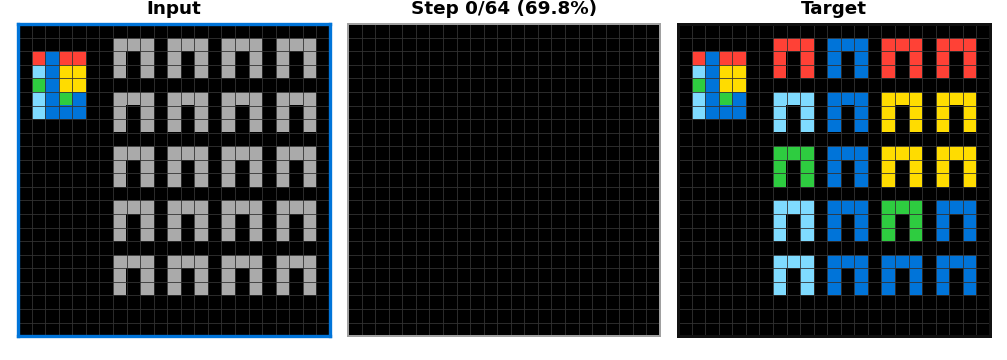

In [8]:

# @title 6. evaluate eval task and plot the rollout (Eval Task 33b52de3)
rollout_stats = plot_nca_rollout_publication_hq(
    params=eval_params,
    task_str=ROLLOUT_TASK_ID,
    preds_dir=AUGMENTED_EVAL_DIR,
    sample_idx=ROLLOUT_SAMPLE_IDX,
    iter_n=ROLLOUT_ITER_N,
    steps_to_show=list(range(ROLLOUT_ITER_N + 1)),
    seed=ROLLOUT_SEED,
    show_target=ROLLOUT_SHOW_TARGET,
    save_gif_path=os.path.join(
        OUTPUT_DIR, f"rollout_{ROLLOUT_TASK_ID}_sample{ROLLOUT_SAMPLE_IDX}.gif"
    ),
)

Saved rollout GIF to: ./outputs/rollout_pretrained_a8d7556c_sample0.gif



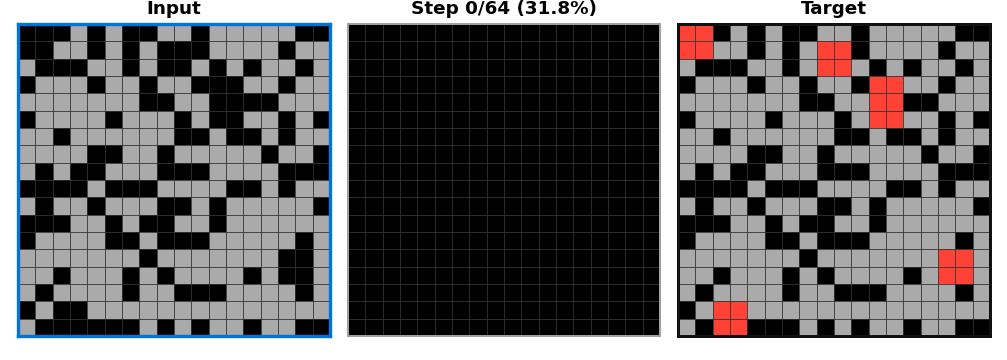

In [9]:
# @title run pretrained model and plot rollout on ARC-AGI-1 Public Training Dataset
ROLLOUT_TRAIN_TASK_ID = "a8d7556c"  # @param {type:"string"}

#evaluating on the "test" image on the ARC-AGI-1 Public Training Dataset
pretrained_train_stats = plot_nca_rollout_publication_hq(
    params=params,
    task_str=ROLLOUT_TRAIN_TASK_ID,
    preds_dir=None,
    sample_idx=0,
    iter_n=ROLLOUT_ITER_N,
    steps_to_show=list(range(ROLLOUT_ITER_N + 1)),
    seed=ROLLOUT_SEED,
    show_target=ROLLOUT_SHOW_TARGET,
    save_gif_path=os.path.join(
        OUTPUT_DIR, f"rollout_pretrained_{ROLLOUT_TRAIN_TASK_ID}_sample0.gif"
    ),
)

Running NCA rollout for Task ID 101...
Saved rollout video (MP4) to: output/task_101/rollout_task_101.mp4


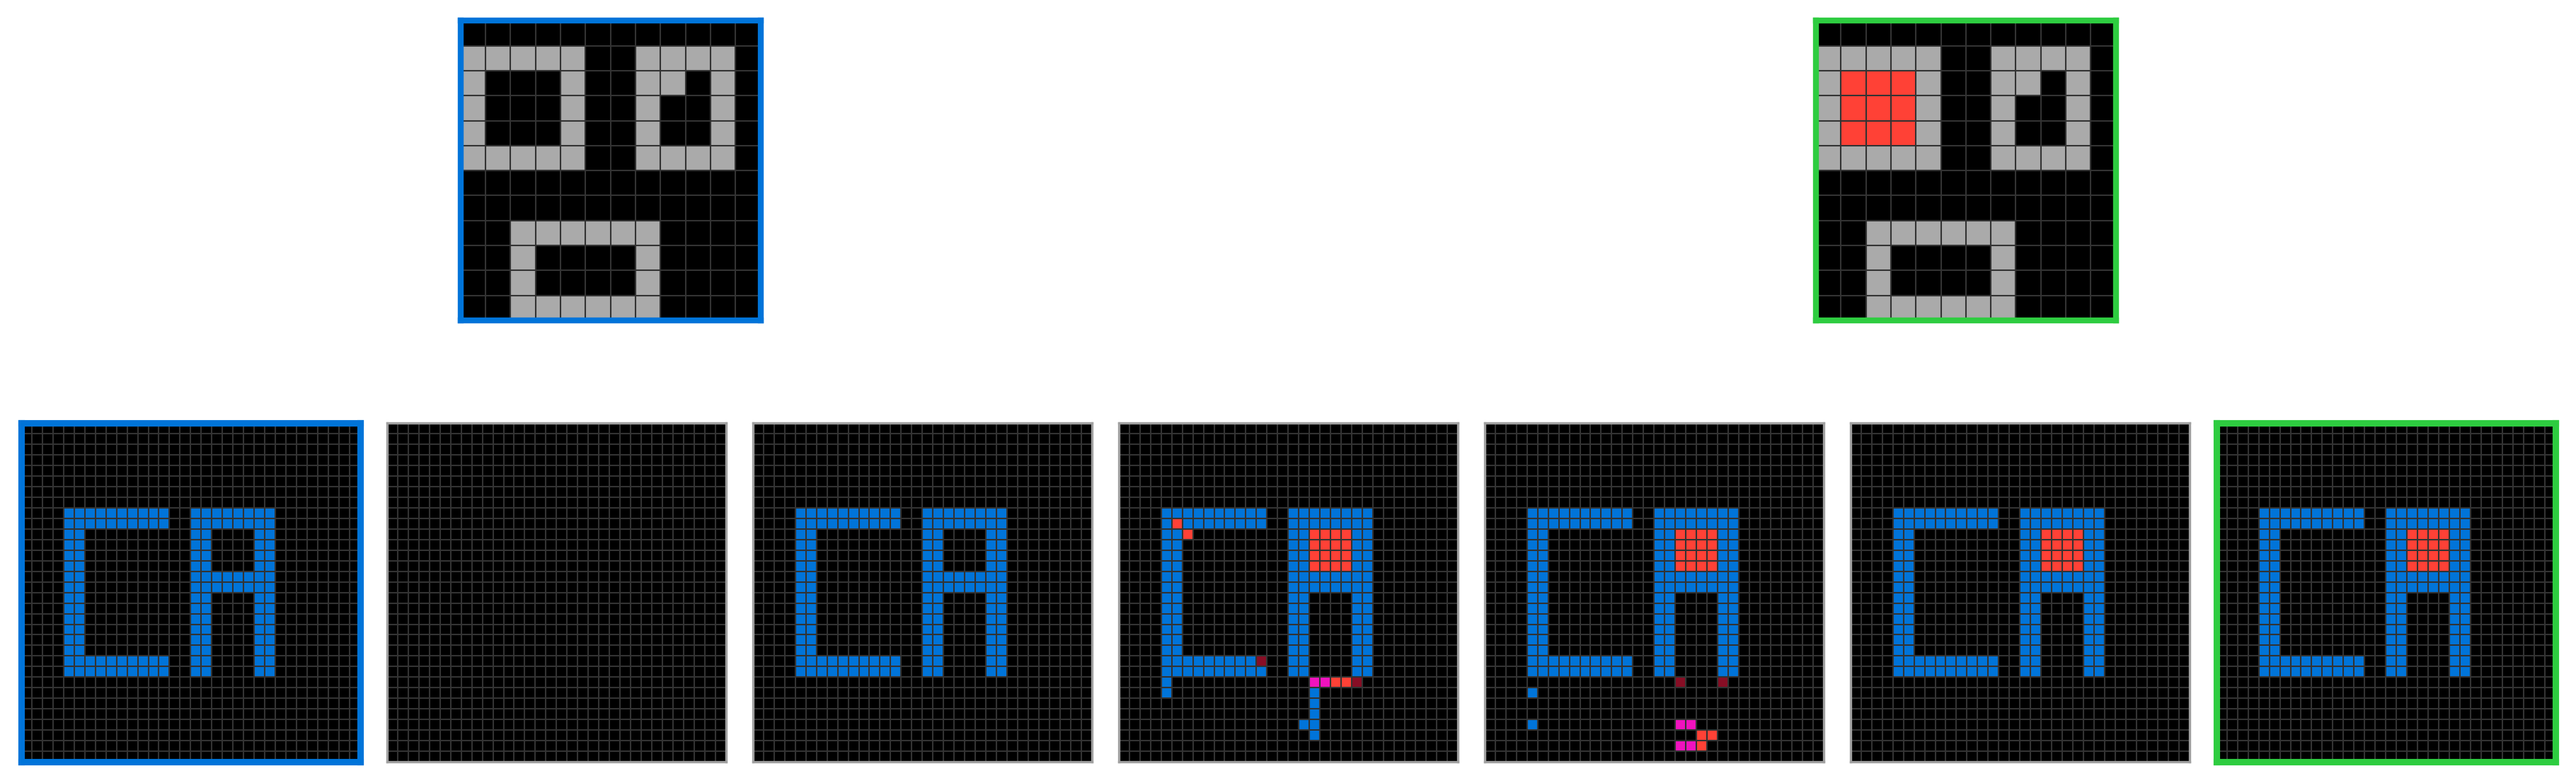

Running NCA rollout for Task ID 197...
Saved rollout video (MP4) to: output/task_197/rollout_task_197.mp4


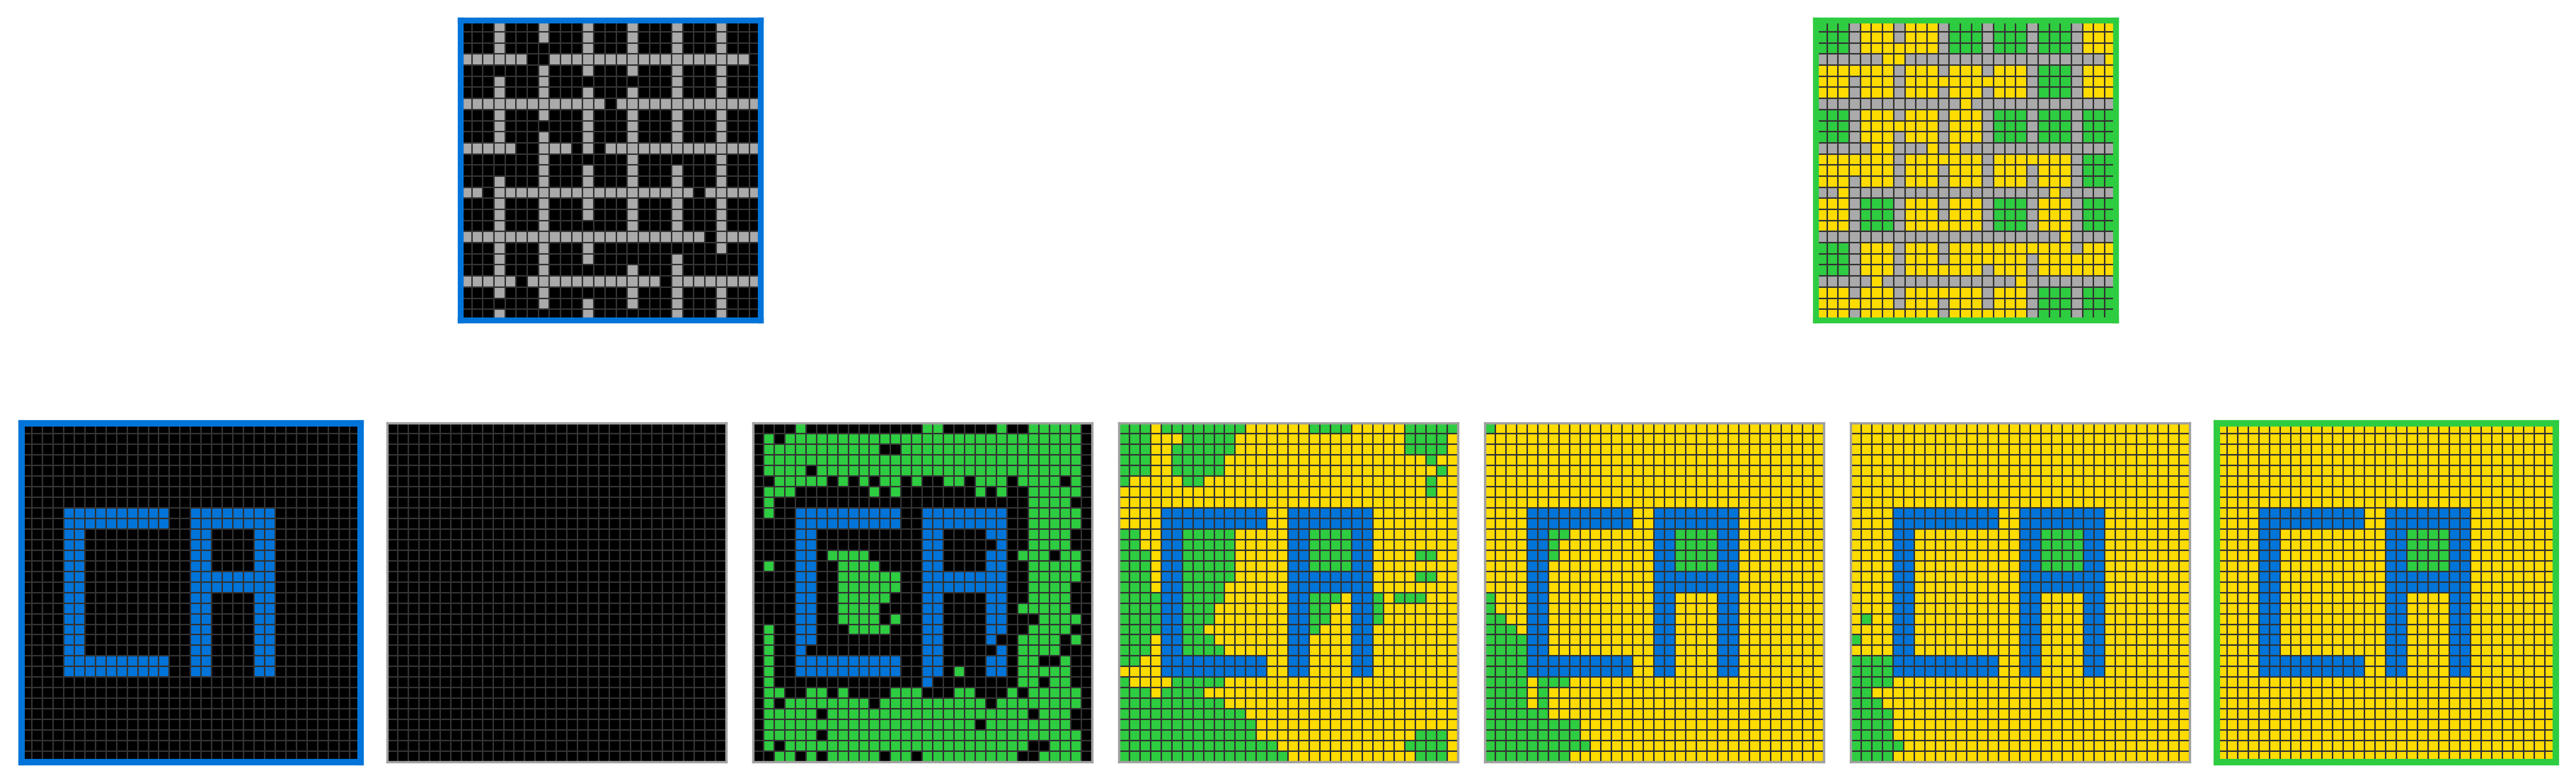

In [10]:

# @title 7. NCA transfer task embedding
def build_ca_grid(grid_size: int = 32, class_val: int = 1) -> np.ndarray:
    """Creates a 32x32 ARC grid with 'CA' geometric glyphs."""
    ca_grid = np.zeros((grid_size, grid_size), dtype=np.int32)

    # 'C'
    ca_grid[8:10, 4:14] = class_val
    ca_grid[8:24, 4:6] = class_val
    ca_grid[22:24, 4:14] = class_val

    # 'A'
    ca_grid[8:24, 16:18] = class_val
    ca_grid[8:24, 22:24] = class_val
    ca_grid[8:10, 16:24] = class_val
    ca_grid[14:16, 16:24] = class_val

    return ca_grid


def generate_rollout_video(
    preds_seq: List[np.ndarray],
    task_id: int,
    output_path: str = "output/rollout.mp4",
    fps: int = 8,
) -> FuncAnimation:
    """Creates an animation of the NCA state rollout."""
    total_frames = len(preds_seq)
    fig, ax_state = plt.subplots(figsize=(3.5, 3.5), dpi=150, facecolor="#111111")
    plt.subplots_adjust(top=0.88, bottom=0.05, left=0.05, right=0.95)

    def update(frame_idx: int):
        ax_state.clear()
        plot_grid(preds_seq[frame_idx], ax=ax_state)
        ax_state.set_title("NCA State", color="#AAAAAA", fontsize=9)
        fig.suptitle(
            f"Task {task_id} Rollout (Step {frame_idx} / {total_frames - 1})",
            color="white",
            fontsize=11,
            fontweight="bold",
        )
        return []

    anim = FuncAnimation(
        fig,
        update,
        frames=total_frames,
        init_func=lambda: update(0),
        blit=False,
        interval=1000 / fps,
    )

    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    anim.save(output_path, writer=FFMpegWriter(fps=fps, metadata={"artist": "NCA ARC"}))
    print(f"Saved rollout video (MP4) to: {output_path}")

    display(HTML(anim.to_jshtml()))
    plt.close(fig)
    return anim


def plot_ca_transfer_task_embedding(
    params: Dict[str, Any],
    task_id: int,
    t_inputs: Any,
    t_targets: Any,
    t_ids: Any,
    sample_idx: int = 0,
    iter_n: int = 64,
    steps_to_show: List[int] = [0, 8, 16, 28, 40, 64],
    seed: int = 2,
    ca_class_val: int = 3,
    output_dir: str = "output",
    video_fps: int = 8,
) -> Tuple[plt.Figure, np.ndarray]:
    """Plots 2-row combined figure, saves task/CA inputs & targets, intermediate cells, and video."""
    task_indices = np.where(np.array(t_ids) == task_id)[0]
    if len(task_indices) == 0:
        raise ValueError(f"Task ID {task_id} not found in t_ids dataset.")

    idx = task_indices[sample_idx]
    pad_tokens = (PAD_INDEX, 10, 11)

    cropped_orig_in = crop_target(np.array(t_inputs[idx]), pad_tokens)
    cropped_orig_tgt = crop_target(np.array(t_targets[idx]), pad_tokens)

    ca_grid = build_ca_grid(grid_size=32, class_val=ca_class_val)

    print(f"Running NCA rollout for Task ID {task_id}...")
    preds_hist = np.array(
        run_rollout(
            params=params,
            x_input=jnp.array(ca_grid),
            local_tid=task_id,
            rng_key=jr.PRNGKey(seed),
            iter_n=iter_n,
        )
    )

    cy0, cy1, cx0, cx1 = get_content_bounds(
        preds_hist, pad_values=(0, *pad_tokens), margin=1
    )
    cropped_ca_in = ca_grid[cy0 : cy1 + 1, cx0 : cx1 + 1]
    cropped_ca_preds = [p[cy0 : cy1 + 1, cx0 : cx1 + 1] for p in preds_hist]

    valid_steps = [s for s in steps_to_show if s < len(cropped_ca_preds)]
    total_cols = 1 + len(valid_steps)

    fig = plt.figure(figsize=(2.2 * total_cols, 4.6), dpi=300, facecolor="none")
    gs_main = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1.0, 1.2], hspace=0.28)
    gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0], wspace=0.15)

    plot_grid(
        cropped_orig_in,
        ax=fig.add_subplot(gs_top[0, 0]),
        border_color="#0074D9",
        border_width=2.0,
    )
    plot_grid(
        cropped_orig_tgt,
        ax=fig.add_subplot(gs_top[0, 1]),
        border_color="#2ECC40",
        border_width=2.0,
    )

    gs_mid = gridspec.GridSpecFromSubplotSpec(
        1, total_cols, subplot_spec=gs_main[1], wspace=0.08
    )
    plot_grid(
        cropped_ca_in,
        ax=fig.add_subplot(gs_mid[0, 0]),
        border_color="#0074D9",
        border_width=2.2,
    )

    for idx_col, s_idx in enumerate(valid_steps):
        is_final = idx_col == len(valid_steps) - 1
        plot_grid(
            cropped_ca_preds[s_idx],
            ax=fig.add_subplot(gs_mid[0, 1 + idx_col]),
            border_color="#2ECC40" if is_final else "#A0A0A0",
            border_width=2.2 if is_final else 0.8,
        )

    task_dir = os.path.join(output_dir, f"task_{task_id}")
    os.makedirs(task_dir, exist_ok=True)

    for fmt, transparent in [("png", False), ("pdf", True)]:
        fig.savefig(
            os.path.join(task_dir, f"publication_panel_task_{task_id}.{fmt}"),
            bbox_inches="tight",
            dpi=300,
            transparent=transparent,
            facecolor="white" if not transparent else "none",
        )

    preds_dir = os.path.join(task_dir, "states")
    cells_to_save = [
        (cropped_orig_in, "task_input", "#0074D9", 2.0),
        (cropped_orig_tgt, "task_target", "#2ECC40", 2.0),
        (cropped_ca_in, "ca_input", "#0074D9", 2.2),
        (cropped_ca_preds[-1], "ca_target", "#2ECC40", 2.2),
    ]
    for s in valid_steps:
        is_last = s == len(cropped_ca_preds) - 1
        cells_to_save.append(
            (
                cropped_ca_preds[s],
                f"state_step_{s:03d}",
                "#2ECC40" if is_last else "#A0A0A0",
                2.0 if is_last else 0.8,
            )
        )

    for grid_cell, name, b_col, b_w in cells_to_save:
        render_and_save_standalone_cell(
            grid_cell,
            save_name=name,
            output_dir=preds_dir,
            border_color=b_col,
            border_width=b_w,
        )

    generate_rollout_video(
        preds_seq=cropped_ca_preds,
        task_id=task_id,
        output_path=os.path.join(task_dir, f"rollout_task_{task_id}.mp4"),
        fps=video_fps,
    )

    return fig, preds_hist


STEPS_TO_SHOW = [0, 8, 28, 34, 40, 64]
TASKS_TO_RUN = [101, 197]

for task_id in TASKS_TO_RUN:
    fig, preds_hist = plot_ca_transfer_task_embedding(
        params=params,
        task_id=task_id,
        t_inputs=t_inputs,
        t_targets=t_targets,
        t_ids=t_ids,
        sample_idx=0,
        iter_n=64,
        steps_to_show=STEPS_TO_SHOW,
        seed=2,
        ca_class_val=1,
        output_dir="output",
        video_fps=8,
    )
    plt.show()